In [1]:
import numpy as np
import keras
import datetime
import os
import random
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2
from keras.datasets import imdb
from time import time
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import f1_score
from sklearn.metrics.pairwise import cosine_similarity
from tmu.models.autoencoder.autoencoder import TMAutoEncoder
from contextlib import redirect_stdout
from tqdm import tqdm

target_words = ['london', 'city', 'lousy', 'abysmal', 'crap', 'terrible', 'brilliant', 'excellent', 'superb', 'magnificent', 'marvellous', 'truck', 'plane', 'car', 'cars', 'motorcycle',  'scary', 'frightening', 'terrifying', 'horrifying', 'funny', 'comic', 'hilarious', 'witty']

home_dir = os.path.expanduser("~")
root_folder = os.path.join(home_dir, "tmu_results")
if not os.path.exists(root_folder):
    os.makedirs(root_folder)

2023-12-12 12:43:29,278 - tmu.util.cuda_profiler - WARNING - Could not import pycuda: No module named 'pycuda'
2023-12-12 12:43:29,282 - tmu.clause_bank.clause_bank_cuda - ERROR - No module named 'pycuda'
Traceback (most recent call last):
  File "C:\Users\ahmedkk\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tmu\clause_bank\clause_bank_cuda.py", line 41, in <module>
    from pycuda._driver import Device, Context
ModuleNotFoundError: No module named 'pycuda'
2023-12-12 12:43:29,304 - tmu.clause_bank.clause_bank_cuda - WARNING - Could not import pycuda. This indicates that it is not installed! A possible fix is to run 'pip install pycuda'. Fallback to CPU ClauseBanks.


In [2]:
experts_dataset = []
def prepare_bbc():
    from nltk.tokenize import word_tokenize
    # training_data = []
    import re
    data_dir ="bbc"
    for category in os.listdir(data_dir):
        category_dir = os.path.join(data_dir, category)
        print("the number of news in train set =",len(os.listdir(category_dir)))
        for file_name in os.listdir(category_dir):
            file_path = os.path.join(category_dir, file_name)
            with open(file_path, "r") as file:
                content = file.read()
                preprocessed_content = re.sub(r'\W+', ' ', content.lower())
                tokens = word_tokenize(preprocessed_content)
                document_tokens = ['<start>'] + tokens + ['<end>']
                experts_dataset.append(document_tokens)
    # experts_dataset.append((training_data,"BBC Sport"))

def prepare_20newsgroups():
    from sklearn.datasets import fetch_20newsgroups
    import re
    # training_data = []
    newsgroups_data = fetch_20newsgroups(subset='train', remove=('headers', 'footers', 'quotes'))
    documents = newsgroups_data.data
    print("the number of news in train set =",len(documents))
    for document in documents:
        preprocessed_content = re.sub(r'\W+', ' ', document.lower()).split()
        document_tokens = ['<start>'] + preprocessed_content + ['<end>']
        experts_dataset.append(document_tokens)
    # experts_dataset.append((training_data,"20 Newsgroups"))

def prepare_ag_news():
    # pip install tensorflow_datasets
    # pip install datasets
    import os
    os.environ["CUDA_VISIBLE_DEVICES"] = "-1"
    import tensorflow_datasets as tfds
    data = tfds.load('ag_news', split='train[:25000]')
    print("the number of news in train set =",len(data))
    # training_data = []
    for sample in data:
        # Append the preprocessed text along with its label to the training data list
        document = ['<start>'] + sample['text'].numpy().decode('utf-8').split() + ['<end>']
        experts_dataset.append(document)

def prepare_imdb():
    # training_data = []
    NUM_WORDS=10000
    INDEX_FROM=2
    train,test = keras.datasets.imdb.load_data(num_words=NUM_WORDS, index_from=INDEX_FROM)
    train_x,train_y = train
    print("the number of reviews in train set =",train_x.size)
    word_to_id = keras.datasets.imdb.get_word_index()
    word_to_id = {k:(v+INDEX_FROM) for k,v in word_to_id.items()}
    word_to_id["<PAD>"] = 0
    word_to_id["<START>"] = 1
    word_to_id["<UNK>"] = 2
    id_to_word = {value:key for key,value in word_to_id.items()}
    for i in range(train_y.shape[0]):
        terms = []
        for word_id in train_x[i]:
            terms.append(id_to_word[word_id].lower())             
        experts_dataset.append(terms)
    # experts_dataset.append((training_data,"IMDB"))

In [3]:
experts_dataset = []
involved_datasets = []
print(len(experts_dataset))

# print("start preparing BBC Sport datatsets")
# old_length = len(experts_dataset)
# prepare_bbc()
# involved_datasets.append(["BBC",old_length,len(experts_dataset)])
# print(len(experts_dataset))

print("start preparing 20 Newsgroups datatsets")
old_length = len(experts_dataset)
prepare_20newsgroups()
involved_datasets.append(["20 News",old_length,len(experts_dataset)])
print(len(experts_dataset))

# print("start preparing AG News datatsets")
# old_length = len(experts_dataset)
# prepare_ag_news()
# involved_datasets.append(["AG News",old_length,len(experts_dataset)])
# print(len(experts_dataset))

print("start preparing IMDB datatsets")
old_length = len(experts_dataset)
prepare_imdb()
involved_datasets.append(["IMDB",old_length,len(experts_dataset)])
print(len(experts_dataset))

print("datatsets completed")

0
start preparing 20 Newsgroups datatsets
the number of news in train set = 11314
11314
start preparing IMDB datatsets
the number of reviews in train set = 25000
36314
datatsets completed


In [4]:
print(experts_dataset[involved_datasets[0][1] - 1])
print(involved_datasets)

['<start>', 'as', 'a', 'big', 'fan', 'of', 'the', 'original', 'film', "it's", 'hard', 'to', 'watch', 'this', 'show', 'the', '<unk>', 'set', '<unk>', 'and', '<unk>', '<unk>', 'sets', 'rob', 'any', 'style', 'from', 'this', 'remake', 'the', 'mood', 'is', 'never', 'there', 'instead', 'it', 'has', 'the', 'look', 'and', 'feel', 'of', 'so', 'many', 'television', 'movies', 'of', 'the', 'seventies', 'crenna', 'is', 'not', 'a', 'bad', 'choice', 'as', 'walter', '<unk>', 'but', 'his', 'snappy', 'wardrobe', 'and', '<unk>', 'apartment', "don't", 'fit', 'the', 'mood', 'of', 'the', 'original', 'or', 'make', 'him', 'an', 'interesting', 'character', 'he', 'does', 'his', 'best', 'to', 'make', 'it', 'work', 'but', 'samantha', '<unk>', 'is', 'a', 'really', 'bad', 'choice', 'the', 'english', 'accent', 'and', 'california', 'looks', "can't", 'hold', 'a', 'candle', 'to', 'barbara', '<unk>', '<unk>', 'voice', 'and', 'sex', 'appeal', 'lee', 'j', '<unk>', 'tries', '<unk>', 'to', 'fashion', 'barton', '<unk>', 'but

In [5]:
def tokenizer(s):
    return s
vectorizer_X = CountVectorizer(tokenizer=tokenizer, lowercase=False, binary = True)
X_train = vectorizer_X.fit_transform(experts_dataset)
feature_names = vectorizer_X.get_feature_names_out()
number_of_features = vectorizer_X.get_feature_names_out().shape[0]
print("No of features: %d" % number_of_features)
output_active = np.empty(len(target_words), dtype=np.uint32)
for i in range(len(target_words)):
    target_word = target_words[i]
    if target_word in vectorizer_X.vocabulary_:
        target_id = vectorizer_X.vocabulary_[target_word]
        output_active[i] = target_id
    else:
        # Handle the case when the word is not in the vocabulary
        print(f"Warning: '{target_word}' not found in voc abulary.")
print("tokenizing target words completed")

C:\Users\ahmedkk\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\feature_extraction\text.py:525: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


No of features: 102845
tokenizing target words completed


In [6]:
# london was 58033
# target_id = vectorizer_X.vocabulary_["london"]
target_id = 58192
print(vectorizer_X.get_feature_names_out()[target_id])

print(experts_dataset[8676])
print(experts_dataset[17748])


lousy
['<start>', 'tommy', 'frandsen', 's', 'vgalib', 'which', 'is', 'probably', 'what', 'you', 're', 'talking', 'about', 'will', 'do', 'the', 'standard', 'vga', 'modes', 'some', 'tweaked', 'modes', 'and', 'then', 'the', 'tseng', 'et4000', 'super', 'vga', 'modes', 'i', 'have', 'an', 'et4000', 'and', 'i', 'm', 'viewing', 'gif', 's', 'at', '640x480', '256', 'i', 'have', 'a', 'lousy', 'small', 'monitor', 'with', 'dpg', 'view', 'on', 'linux', 'i', 'think', 'i', 'had', 'to', 'change', 'some', 'constants', 'in', 'the', 'dpg', 'view', 'sources', 'to', 'make', 'it', 'use', 'the', 'et4k', 'modes', 'vgalib', 's', 'sources', 'seem', 'to', 'be', 'designed', 'for', 'easy', 'addition', 'of', 'new', 'super', 'vga', 'support', 'each', 'mode', 'is', 'an', 'array', 'of', 'register', 'values', 'and', 'there', 's', 'a', 'program', 'that', 'dumps', 'an', 'array', 'declaration', 'of', 'this', 'kind', 'describing', 'the', 'current', 'mode', 'haven', 't', 'tried', 'it', 'though', 'btw', 'my', 'version', 'of',

In [7]:
terms = []
data_list = X_train[involved_datasets[0][1] - 1]
original_document = vectorizer_X.inverse_transform(data_list)

print("Original document:", original_document)

Original document: [array(['<start>', 'was', 'there', 'me', 'this', 'the', 'it', 'a', 'to',
       'from', 'really', 'of', 'is', 'or', 'and', 'so', 'as', 'does',
       'any', 'make', 'an', 'but', 'has', 'like', 'just', 'what', 'feel',
       'looks', 'set', 'show', 'not', 'instead', 'still', 'work', 'hard',
       'without', 'even', 'his', 'never', 'hold', 'he', 'look', 'many',
       'performance', 'interesting', 'appeal', 'again', 'california',
       'best', 'voice', 'big', 'style', 'him', 'bad', 'movies', 'sets',
       'original', 'j', 'watch', 'fit', 'fashion', 'choice', 'apartment',
       'tv', 'character', 'feels', 'movie', 'sex', 'fan', 'remarkable',
       'br', 'english', 'accent', 'television', 'rob', 'walter', 'lee',
       'tries', 'barbara', 'candle', 'film', 'mood', 'reminds',
       'seventies', 'barton', 'snappy', 'remake', 'wardrobe', '<unk>',
       "don't", "it's", "can't", 'gruff', 'crenna', 'samantha'],
      dtype='<U81')]


In [8]:
num_segments = len(target_words)
step_size = int(360 / num_segments)
color_dict = {}
hue = 0
for word in target_words:
    color = plt.get_cmap('hsv')(hue / 360.0)
    color = mcolors.to_rgb(color)
    hex_color = mcolors.rgb2hex(color)
    color_dict[word] = hex_color
    hue += step_size

Running Epochs:  50%|█████     | 1/2 [00:22<00:22, 22.34s/it]

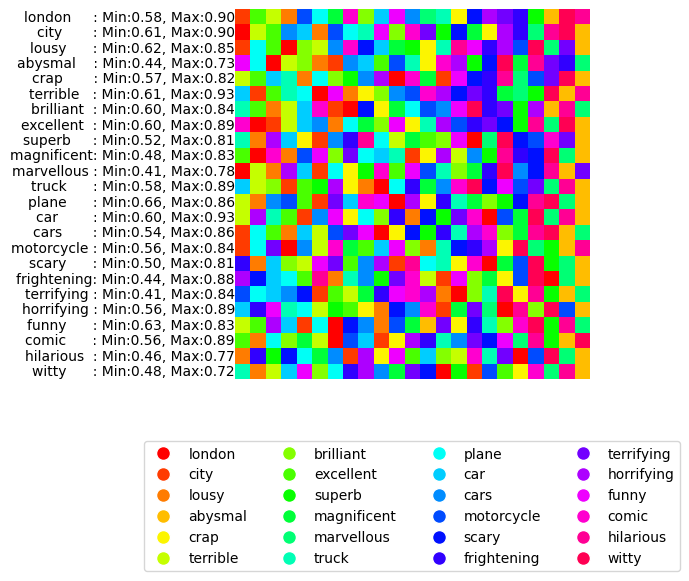

Running Epochs: 100%|██████████| 2/2 [01:27<00:00, 47.41s/it]

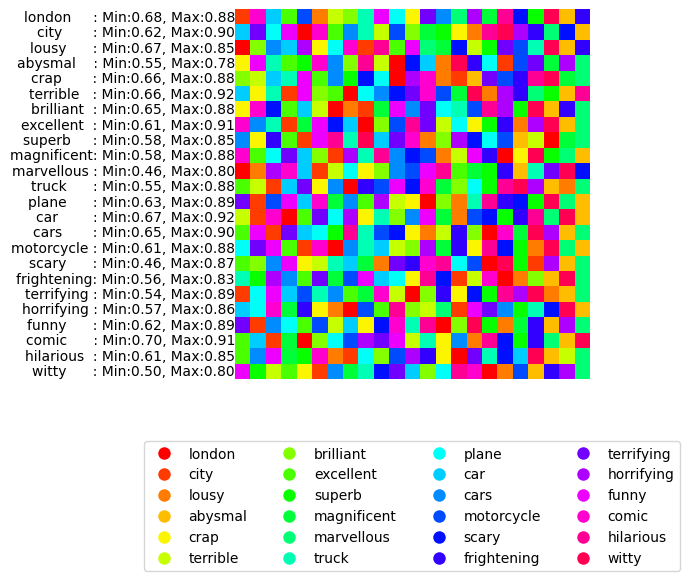

Running Epochs: 100%|██████████| 2/2 [01:28<00:00, 44.16s/it]


In [9]:
current_time = datetime.datetime.now()
test_id = current_time.strftime("%Y%m%d%H%M%S")
result_filename = f"result_{test_id}.txt"
while os.path.exists(os.path.join(root_folder, test_id)):
        test_id = str(uuid.uuid4())
test_dir = os.path.join(root_folder, test_id)
os.makedirs(test_dir)
result_filepath = os.path.join(test_dir, result_filename)
clauses_dir = os.path.join(test_dir, 'clauses_variance_plots')
if not os.path.exists(clauses_dir):
    os.makedirs(clauses_dir)
    
with open(result_filepath, 'w') as file, redirect_stdout(file):
    # parameters
    clause_weight_threshold = 0
    number_of_examples = 200
    factor = 4
    T = factor*40
    s = 5.0
    #clauses = factor*5
    clauses = 40
    clause_increment = False
    random_per_category = False
    categories = 0
    accumulation = 24
    epochs = 2
    fluctuations = []
    progress_bar = tqdm(total=epochs, desc="Running Epochs")
    
    print("Test: %s" % test_id)
    tm = TMAutoEncoder(clauses, T, s, output_active, max_included_literals=3, accumulation=accumulation, feature_negation=False, platform='CPU', output_balancing=True)
    total_training = 0
    if(categories > 0): 
        print("Algorithm: With %d categories and random per category" % categories) if(random_per_category) else print("Algorithm: With %d categories" % categories) 
    else: 
        print("Algorithm: Original without categories")
    print("Epochs: %d" % epochs)
    print("Example: %d" % number_of_examples)
    print("Target words: %d" % len(target_words))
    print("Accumulation: %d" % accumulation)
    print("Datasets involved: %s" % involved_datasets)
    print("No of features: %d" % number_of_features)
    print("Clauses: %d with increment by 2\n" % clauses) if clause_increment else print("Clauses: %d\n" % clauses)
    
    for e in range(epochs):
        print("\nEpoch #%d" % (e+1))
        start_training = time()
        if categories > 0:
             tm.fit(
                X_train, 
                number_of_examples=number_of_examples, 
                categories=categories, 
                random_per_category = random_per_category
                )
        else:
            tm.fit(
                X_train, 
                number_of_examples=number_of_examples, 
                involved_datasets=involved_datasets 
                )
        stop_training = time()
        total_training = total_training + (stop_training - start_training)

        
        if((e+1) == epochs):
            print("\n=====================================\nClauses\n=====================================")
            for j in range(clauses):
                print("Clause #%-2d " % (j), end=' ')
                l = [] 
                number_of_literals = 0 
                for k in range(tm.clause_bank.number_of_literals):
                    if tm.get_ta_action(j, k) == 1:
                        number_of_literals = number_of_literals + 1
                        if k < tm.clause_bank.number_of_features:
                            l.append("%s(%d)" % (feature_names[k], tm.clause_bank.get_ta_state(j, k)))
                        else:
                            l.append("¬%s(%d)" % (feature_names[k-tm.clause_bank.number_of_features], tm.clause_bank.get_ta_state(j, k)))
                print(": No of features:%-6d" % (number_of_literals), end=" ==> ")
                try:
                    print(" ∧ ".join(l))
                except UnicodeEncodeError:
                    print(" exception ")
        
    
        profile = np.empty((len(target_words), clauses))
        for i in range(len(target_words)):
            weights = tm.get_weights(i)
            profile[i,:] = np.where(weights >= clause_weight_threshold, weights, 0)
    
        similarity = cosine_similarity(profile)

        
        print("\n=====================================\nWord Similarity\n=====================================")
        max_word_length = len(max(target_words, key=len))
        list_of_words = []
        target_words_with_min_max = []
        fluctuations_per_epoch = []
        for i in range(len(target_words)):
            row_of_similarity = []
            sorted_index = np.argsort(-1*similarity[i,:])
            min_similarity = 1.0
            max_similarity = 0.0
            word_similarity = []
            for j in range(1, len(target_words)):
                row_of_similarity.append(target_words[sorted_index[j]])
                word_similarity.append("{:<{}}({:.2f})  ".format(target_words[sorted_index[j]], max_word_length, similarity[i, sorted_index[j]]))
                if(min_similarity > similarity[i,sorted_index[j]]):
                    min_similarity = similarity[i,sorted_index[j]]
                if(max_similarity < similarity[i,sorted_index[j]]):
                    max_similarity = similarity[i,sorted_index[j]]
    
            fluctuations_per_epoch.append((target_words[i],min_similarity * 100,max_similarity * 100))
            output_line = f"{target_words[i]:<{max_word_length}}: Min:{min_similarity:.2f}, Max:{max_similarity:.2f}"
            print(output_line, end='     ==> ')
            print(word_similarity)
            list_of_words.append(row_of_similarity)
            target_words_with_min_max.append(output_line)
        fluctuations.append(fluctuations_per_epoch)
        progress_bar.update(1)

        
        # drawing the clauuses variations
        color_array = np.zeros((len(list_of_words), len(list_of_words[0]), 3), dtype=np.uint8)
        for i in range(len(list_of_words)):
            for j in range(len(list_of_words[i])):
                word = list_of_words[i][j]
                # Replace the word with its corresponding color
                color = color_dict[word]
                r, g, b = mcolors.hex2color(color)
                color_array[i][j] = np.array([r*255, g*255, b*255], dtype=np.uint8)
            # Add the row number in front of each row
            plt.text(-0.5, i, f'{target_words_with_min_max[i]}', ha='right', va='center')
        # Create a plot of the color array
        plt.imshow(color_array)
        plt.axis('off')
        # Add legends for each word color
        legend_handles = []
        legend_labels = []
        for word, color in color_dict.items():
            legend_handles.append(plt.Line2D([0], [0], marker='o', color='w', label=word, markerfacecolor=color, markersize=10))
            legend_labels.append(word)
        plt.legend(handles=legend_handles, labels=legend_labels, loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=4)
        plot_filename = os.path.join(clauses_dir,f'clauses_{clauses}_{e+1}.png')
        plt.savefig(plot_filename, dpi=300, bbox_inches='tight')
        plt.show()
        # end of ploting clauses variation

    seconds = total_training
    hours = seconds // 3600
    minutes = (seconds % 3600) // 60
    seconds = seconds % 60
    print(f"Training duration: {hours} hours, {minutes} minutes, {seconds} seconds")
progress_bar.close()

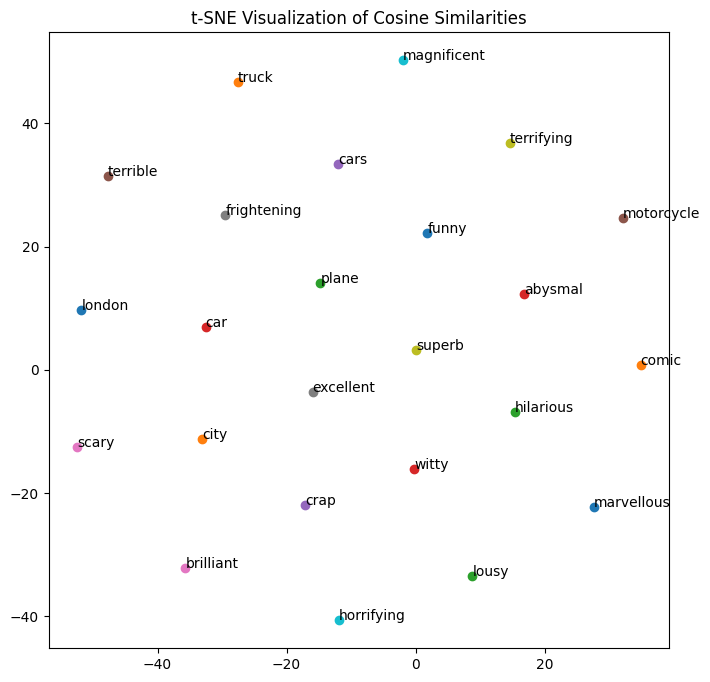

In [10]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import logging

# Set the log level to suppress debug messages from matplotlib.font_manager
logging.getLogger("matplotlib.font_manager").setLevel(logging.INFO)

# Increase the number of samples in the dataset or decrease the perplexity
n_samples = similarity.shape[0]
perplexity = min(30, n_samples - 1)  # You can adjust the perplexity as needed

# Perform t-SNE with adjusted perplexity
tsne = TSNE(n_components=2, perplexity=perplexity, random_state=42)
embeddings = tsne.fit_transform(similarity)

# Plot the results
plt.figure(figsize=(8, 8))
for i, word in enumerate(target_words):
    plt.scatter(embeddings[i, 0], embeddings[i, 1])
    plt.text(embeddings[i, 0], embeddings[i, 1], word)

plt.title('t-SNE Visualization of Cosine Similarities')
result_tSNE_path = os.path.join(test_dir, f"tSNE_{test_id}.png")
plt.savefig(result_tSNE_path, dpi=300, bbox_inches='tight')
plt.show()

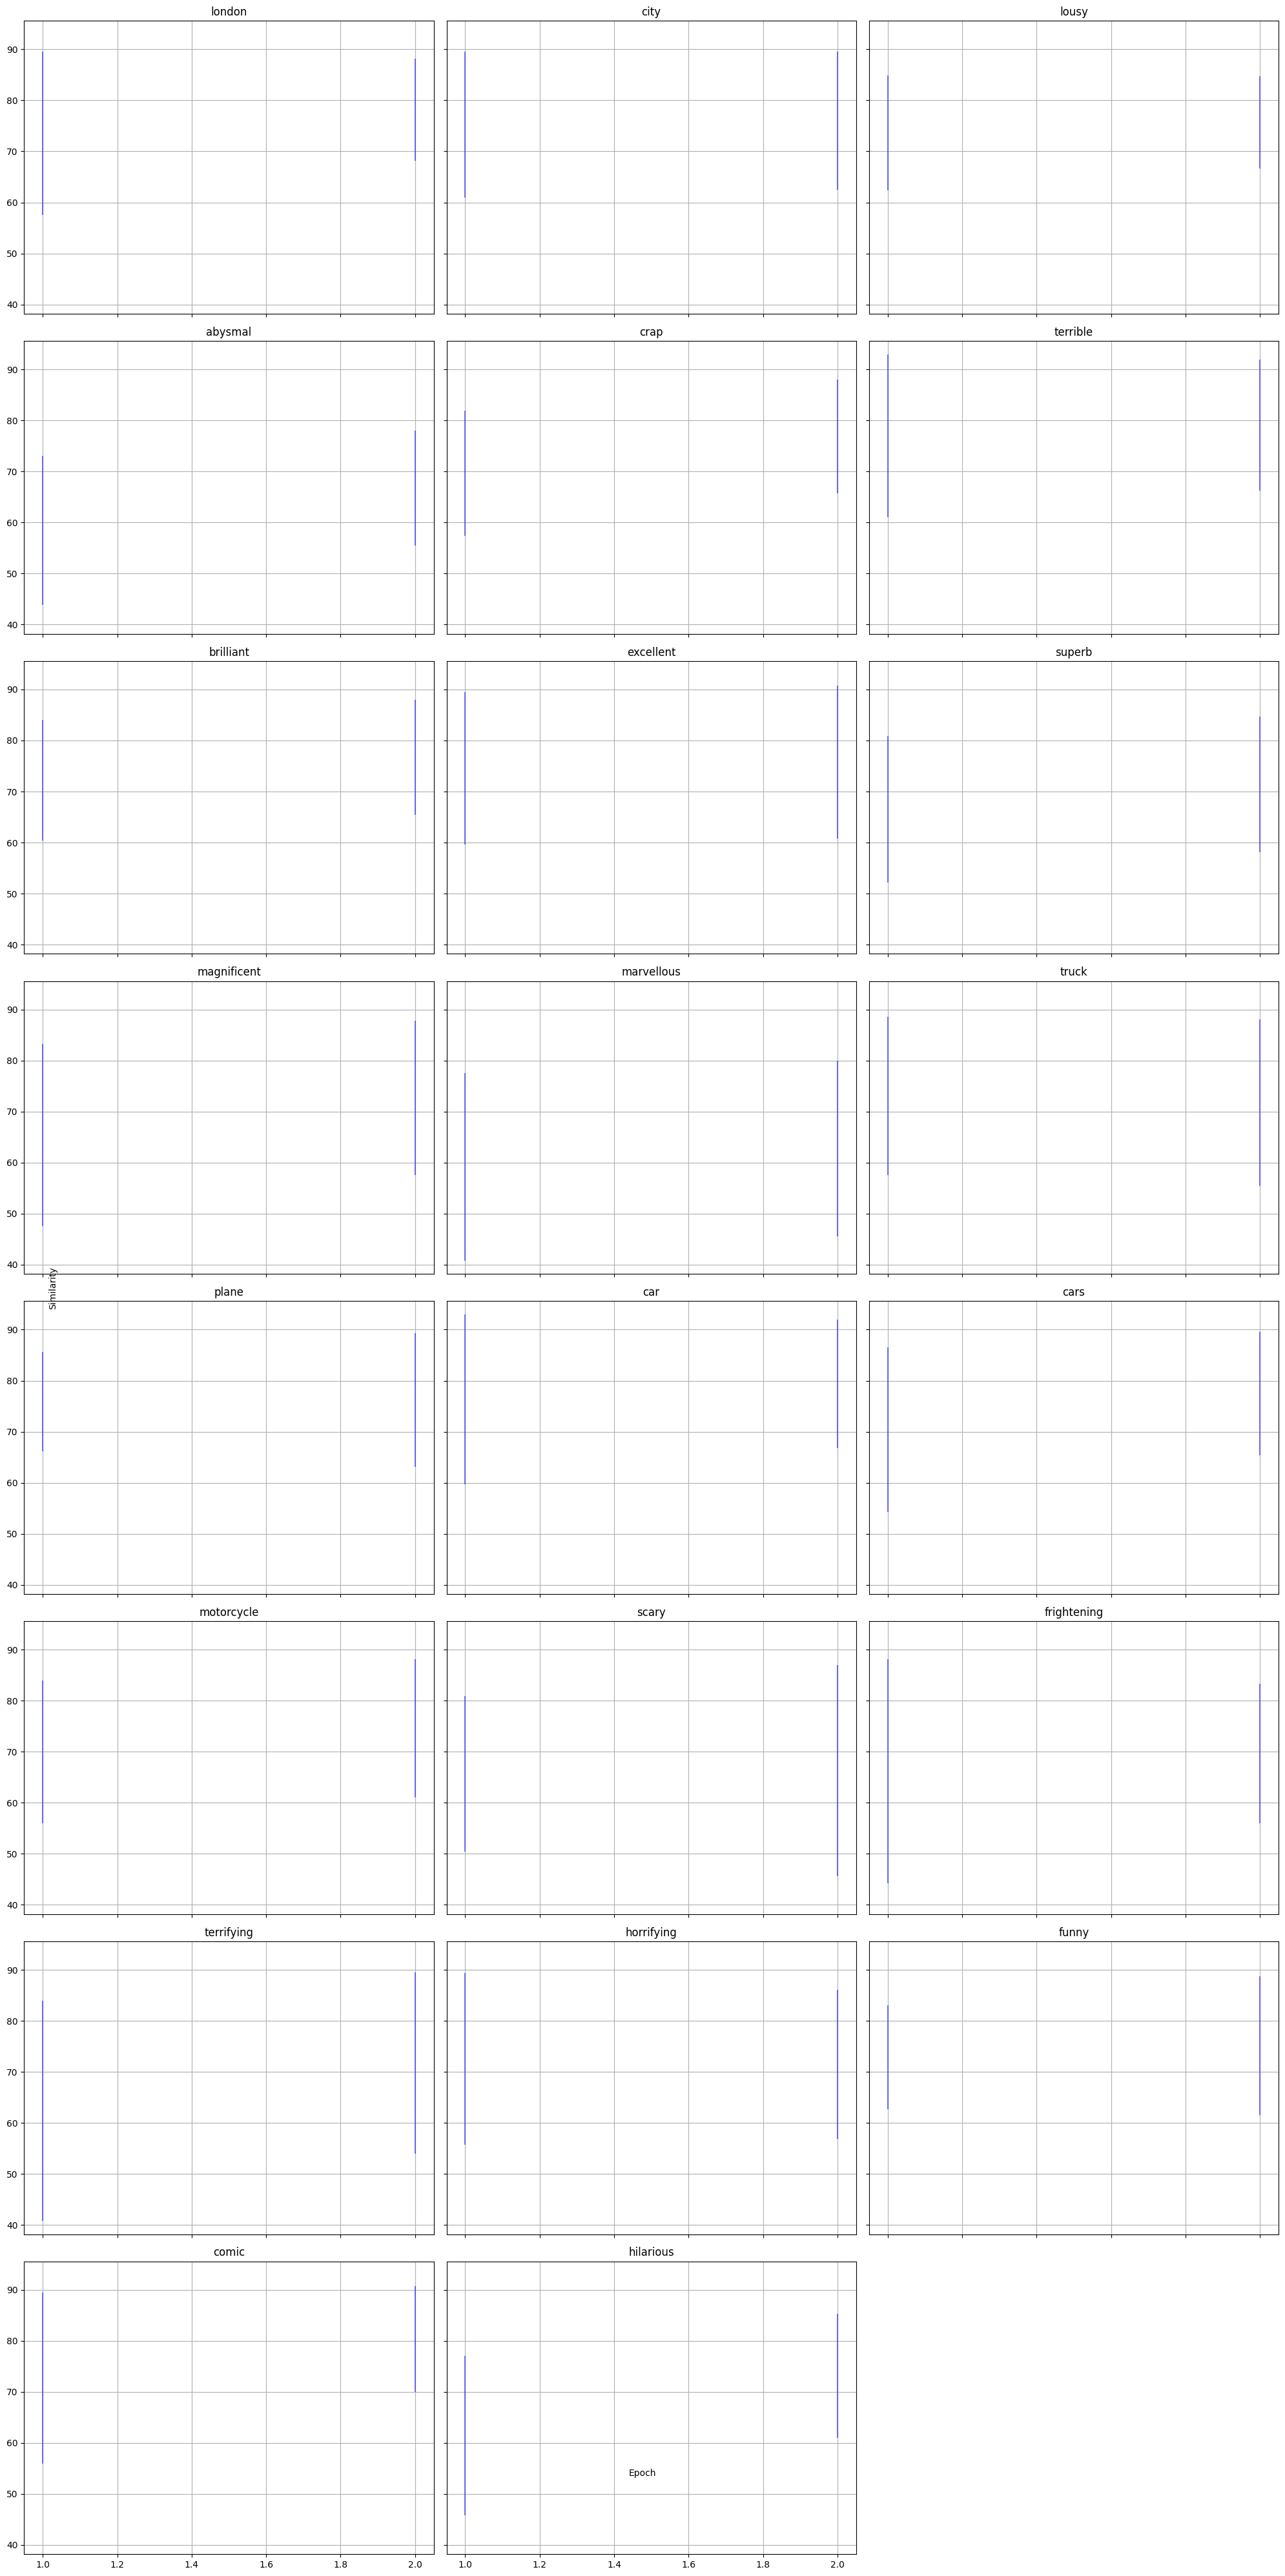

In [11]:
target_words_fluctuations = []
target_word_indices = [target_words.index(word) for word in target_words]
fluctuations_int = np.array(fluctuations.copy())
for target_word_index in target_word_indices:
    target_words_fluctuations.append([[float(item[1]), float(item[2])] for item in fluctuations_int[:, target_word_index]])


num_rows = int(np.ceil(len(target_words) / 3))  # Number of rows in the grid (assumes 3 columns)
fig, axes = plt.subplots(num_rows, 3, figsize=(20, 40), sharex=True, sharey=True)

for i, ax in enumerate(axes.flat):
    if i < len(target_words_fluctuations):
        target_word_fluctuations = target_words_fluctuations[i]
        for epoch, similarity_of_word in enumerate(target_word_fluctuations):
            ax.vlines(epoch+1, similarity_of_word[0], similarity_of_word[1], color='blue', alpha=0.5)  # Set alpha to add transparency to lines

        ax.set_title(target_words[i])
        ax.grid(True)

fig.delaxes(axes[-1, -1])  # Remove any unnecessary subplot

fig.text(0.5, 0.04, 'Epoch', ha='center')  # Common x-axis label
fig.text(0.04, 0.5, 'Similarity', va='center', rotation='vertical')  # Common y-axis label
plt.tight_layout()  # Adjust spacing between subplots
result_image_path = os.path.join(test_dir, f"fluctuations_{test_id}.png")
plt.savefig(result_image_path, dpi=300, bbox_inches='tight')
plt.show()